# Screen Diffraction of a Beam
Examine the diffraction pattern of multiple electron beams passing through a wakefield. this model uses ballistic trajectories.

C:\Users\bryso\AppData\Local\Temp\ipykernel_12704\2543092346.py:48: RuntimeWarning: invalid value encountered in sqrt
  return ( f0/(2*rb) *1/(np.sqrt(1-(i/rb)**2)))


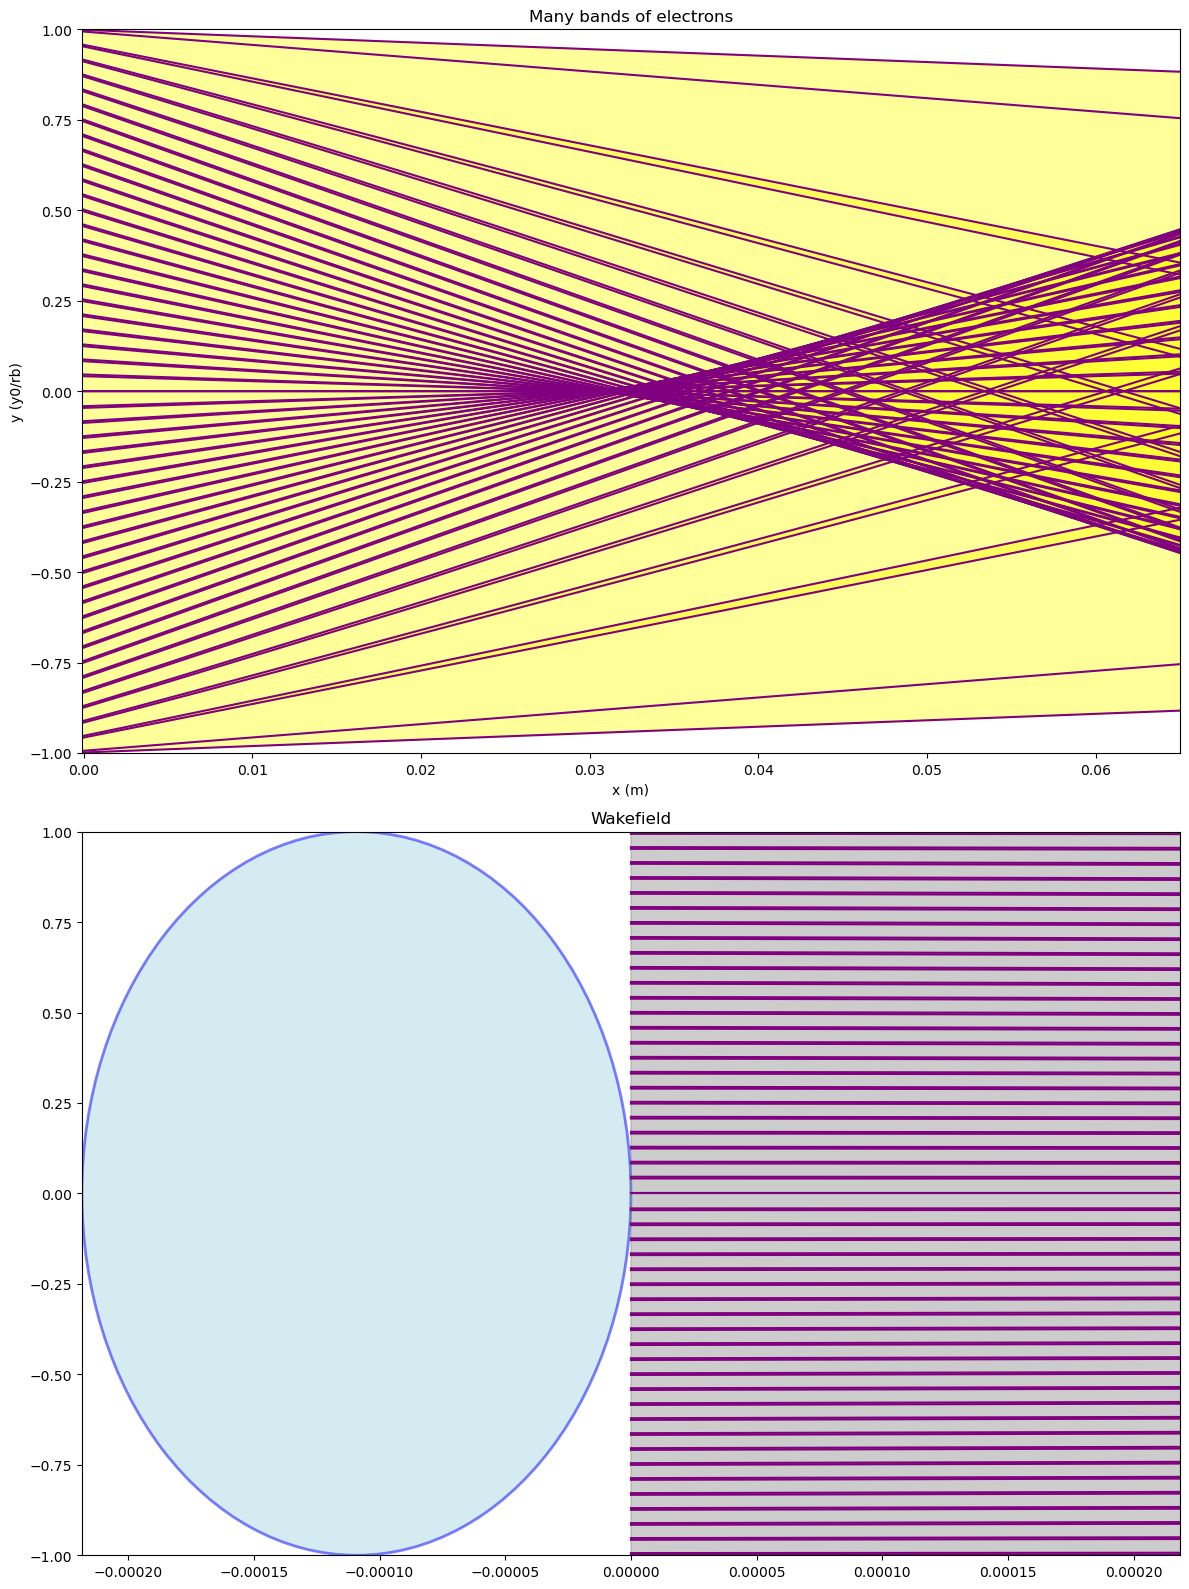

In [1]:
#Bryson Mariano
#6/1/2026

import numpy as np
import scipy.constants as constants
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math
from matplotlib.patches import Ellipse

#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6                 #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)


#Define Parameters


gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65  *c/wp               #c/omega_p   
px    = 110   *me*c                #mec

f0=((px)**2) / (gamma * me * k)


################################################################

epsilon=1e-5

#top
y0= np.linspace((0-epsilon)*c/wp, (0.646-epsilon)* c/wp, 25)
dy=0.03 *c/wp
xmax = 0.065 

#Bottom
y01= np.linspace(-(0.646-epsilon)* c/wp, (0-epsilon)*c/wp, 25)
dy2=-0.03 * (c/wp)

################################################################
#Create/define Focal Length Function

def f_cyl(i):
    return ( f0/(2*rb) *1/(np.sqrt(1-(i/rb)**2)))

def f_cylprime(i):
    return ( f0 /(2*rb) * (1-(i/rb)**2)**(-3/2) * (i/rb**2)  )
              

#############################################################

x = np.linspace(0, xmax, 10)

i=0
electron_l2=[]
electron_h2=[]
electron_low=[]
electron_high=[]
electron_low2=[]
electron_high2=[]

#Assign a beam for each y0 height.
for i in range(len(y0)):
    j=0
    electron_l2=[]
    electron_h2=[]
    while j < len(x): 
        electron_l = -(y0[i]/(f_cyl(y0[i])))*x[j] +y0[i] 
        electron_h = - ((y0[i] +dy)/(f_cyl(y0[i] +dy)))*x[j] + y0[i] +dy 
        electron_l2.append(electron_l)
        electron_h2.append(electron_h)
        f_Tilda = f_cyl(y0[i] )*f_cyl(y0[i] +dy)/(f_cyl(y0[i] )-y0[i] *(f_cyl(y0[i] +dy)-f_cyl(y0[i] ))/dy) 
        j+=1
#Each y0 should now correspond with a set of values 
    electron_low.append(electron_l2)
    electron_high.append(electron_h2)
    i+=1

i=0

#Assign a beam for each y0 height.
for i in range(len(y01)):
    j=0
    electron_l4=[]
    electron_h4=[]
    
    while j < len(x): 
        electron_l3 = -(y01[i]/(f_cyl(y01[i])))*x[j] +y01[i] 
        electron_h3 = - ((y01[i] +dy2)/(f_cyl(y01[i] +dy2)))*x[j] + y01[i] +dy2 
        electron_l4.append(electron_l3)
        electron_h4.append(electron_h3)
        f_Tilda = f_cyl(y01[i] )*f_cyl(y01[i] +dy2)/(f_cyl(y01[i] )-y01[i] *(f_cyl(y01[i] +dy2)-f_cyl(y01[i] ))/dy2) 
        j+=1
#Each y0 should now correspond with a set of values 
    electron_low2.append(electron_l4)
    electron_high2.append(electron_h4)
    i+=1

###Scale Appropriatly

electron_low   = np.array(electron_low)  /rb
electron_high  = np.array(electron_high) /rb
electron_low2  = np.array(electron_low2) /rb
electron_high2 = np.array(electron_high2)/rb


fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(12, 16))

circle = plt.Circle((-rb, 0), rb, color='blue', fill=False)

# 3. Add the patch to the axis
ax1.add_patch(circle)

i=0
for i in range(len(y0)):
    ax1.plot(x, electron_low[i], 'purple')
    ax1.plot(x, electron_high[i], 'purple')
    ax1.fill_between(x, electron_low[i], electron_high[i], color='yellow', alpha=0.4)
    i+=1
    
i=0
for i in range(len(y01)):
    ax1.plot(x, electron_low2[i], 'purple')
    ax1.plot(x, electron_high2[i], 'purple')
    ax1.fill_between(x, electron_low2[i], electron_high2[i], color='yellow', alpha=0.4)
    i+=1


ax1.set_title("Many bands of electrons")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (y0/rb)")

xmin = -rb                                
ax1.set_xlim(xmin, xmax)

ymin = -rb                                /rb
ymax = rb                                 /rb

ax1.set_ylim(ymin, ymax)


#Figure 3 shows the wakefield 
ellipse = Ellipse(xy=(-rb, 0), width=2*rb, height=2,   edgecolor='blue',  facecolor='lightblue',  alpha=0.5,  lw=2)

# 3. Add the patch to the axis
ax3.add_patch(ellipse)

i=0
for i in range(len(y0)):
    ax3.plot(x, electron_low[i], 'purple')
    ax3.plot(x, electron_high[i], 'purple')
    ax3.fill_between(x, electron_low[i], electron_high[i], color='gray', alpha=0.4)
    i+=1
    
i=0
for i in range(len(y0)):
    ax3.plot(x, electron_low2[i], 'purple')
    ax3.plot(x, electron_high2[i], 'purple')
    ax3.fill_between(x, electron_low2[i], electron_high2[i], color='gray', alpha=0.4)
    i+=1


ax3.set_ylim(-rb/rb,rb/rb)
ax3.set_xlim(-2*rb, 2*rb)
ax3.set_title("Wakefield")


plt.tight_layout()
plt.show()

